# 02 - Momentum research

Building the signal, and verifying the weights by hand.

The point of this notebook is the manual verification: a portfolio construction that has never
been checked against arithmetic done by a human is a guess.

In [1]:
%matplotlib inline

import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# Notebooks live in notebooks/; the package lives in src/.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from quant_platform import data, metrics, reporting, signals, validation
from quant_platform.returns import simple_returns, log_returns, cumulative_returns, rolling_volatility

reporting.apply_style()
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 25)

UNIVERSE = ["SPY", "QQQ", "IWM", "EFA", "EEM", "TLT", "GLD", "VNQ", "DBC"]
print("quant_platform loaded from", ROOT / "src")

quant_platform loaded from C:\Users\monis\quant-research-platform\src


In [2]:
long = data.load_prices(UNIVERSE, "2007-01-01", "2025-12-31", data_dir=ROOT / "data", wide=False)
prices = data.to_wide(long, "adjusted_close").dropna()
returns = simple_returns(prices)
print(prices.shape, prices.index[0].date(), "->", prices.index[-1].date())

(4779, 9) 2007-01-03 -> 2025-12-30


## The signal

$$\text{score}_{i,t} = \frac{P_{i,\,t-\text{skip}}}{P_{i,\,t-\text{lookback}}} - 1$$

The `shift(skip)` is what makes the score strictly backward-looking: at date $t$ it depends only
on prices at or before $t - 21$.

In [3]:
scores = signals.trailing_momentum(prices, lookback=252, skip=21)

print("first date with a full cross-section:", scores.dropna(how="any").index[0].date())
print("warm-up length:", scores.isna().all(axis=1).sum(), "trading days")
scores.dropna(how="any").head(3).round(4)

first date with a full cross-section: 2008-01-03
warm-up length: 252 trading days


,DBC,EEM,EFA,GLD,IWM,QQQ,SPY,TLT,VNQ
date,,,,,,,,,
2008-01-03,0.2828,0.3293,0.1246,0.2569,-0.0248,0.1790,0.0583,0.1109,-0.1282
2008-01-04,0.3231,0.3444,0.1207,0.2879,-0.0376,0.1522,0.0466,0.1041,-0.1528
2008-01-07,0.3177,0.4464,0.1510,0.3068,0.0025,0.1786,0.0727,0.0957,-0.1078


### Manual verification of the score

Recompute one cell by hand from raw prices.

In [4]:
test_date = scores.dropna(how="any").index[500]
loc = prices.index.get_loc(test_date)

print(f"date: {test_date.date()}  (index position {loc})\n")
for sym in ["SPY", "TLT"]:
    p_end = prices[sym].iloc[loc - 21]      # t - skip
    p_start = prices[sym].iloc[loc - 252]   # t - lookback
    manual = p_end / p_start - 1
    engine = scores.loc[test_date, sym]
    print(f"{sym}: price[t-252]={p_start:8.2f}  price[t-21]={p_end:8.2f}")
    print(f"     manual={manual:+.6f}  engine={engine:+.6f}  match={np.isclose(manual, engine)}\n")

date: 2009-12-28  (index position 752)

SPY: price[t-252]=   63.58  price[t-21]=   82.68
     manual=+0.300461  engine=+0.300461  match=True

TLT: price[t-252]=   71.68  price[t-21]=   58.72
     manual=-0.180785  engine=-0.180785  match=True



### The skip window, demonstrated

Perturbing the most recent 21 prices must leave today's score untouched. If it does not, the
formation window is not where you think it is.

In [5]:
shocked = prices.copy()
shocked.iloc[-21:] *= 3.0

original_last = signals.trailing_momentum(prices, 252, 21).iloc[-1]
shocked_last  = signals.trailing_momentum(shocked, 252, 21).iloc[-1]

pd.DataFrame({
    "original": original_last,
    "after 3x shock to last 21 prices": shocked_last,
    "identical": np.isclose(original_last, shocked_last),
}).round(6)

,original,after 3x shock to last 21 prices,identical
DBC,0.099142,0.099142,True
EEM,0.290803,0.290803,True
EFA,0.270513,0.270513,True
GLD,0.595754,0.595754,True
IWM,0.110894,0.110894,True
QQQ,0.173697,0.173697,True
SPY,0.146403,0.146403,True
TLT,0.064969,0.064969,True
VNQ,0.049357,0.049357,True


## Ranking and target weights

In [6]:
reb = signals.rebalance_dates(prices.index, "monthly")

print(f"{len(reb)} monthly rebalance dates")
print("all are real trading days:", reb.isin(prices.index).all())
print("first five:", [str(d.date()) for d in reb[:5]])

# Calendar month-ends would NOT all be trading days -- this is the bug the
# platform avoids by resampling the index itself.
cal = pd.date_range(prices.index[0], prices.index[-1], freq="ME")
print(f"\ncalendar month-ends that are NOT trading days: {(~cal.isin(prices.index)).sum()} of {len(cal)}")

228 monthly rebalance dates
all are real trading days: True
first five: ['2007-01-31', '2007-02-28', '2007-03-30', '2007-04-30', '2007-05-31']

calendar month-ends that are NOT trading days: 67 of 227


In [7]:
weights = signals.build_target_weights(
    prices, lookback=252, skip=21, holdings=3, rebalance="monthly", max_weight=0.40
)

assert (weights.abs().sum(axis=1) <= 1.000001).all()
assert (weights >= -1e-12).all().all()

live = weights[weights.sum(axis=1) > 0]
print(f"live from {live.index[0].date()}, {len(live):,} days")
print("positions held per day:", sorted((live > 0).sum(axis=1).unique()))
print("weight per position:", sorted(np.round(live[live > 0].stack().unique(), 6)))

live from 2008-01-31, 4,508 days
positions held per day: [np.int64(3)]
weight per position: [np.float64(0.333333), np.float64(nan)]


### Manual verification of the weights

Take three rebalance dates, rank the scores by hand, and confirm the engine picked the same
three names.

In [8]:
for date in [reb[20], reb[100], reb[-1]]:
    row = scores.loc[date].dropna().sort_values(ascending=False)
    manual_top3 = set(row.head(3).index)
    engine_top3 = set(weights.loc[date][weights.loc[date] > 0].index)

    print(f"--- {date.date()} ---")
    print("  scores:", ", ".join(f"{s}={v:+.3f}" for s, v in row.items()))
    print(f"  manual top 3: {sorted(manual_top3)}")
    print(f"  engine top 3: {sorted(engine_top3)}")
    print(f"  MATCH: {manual_top3 == engine_top3}\n")

--- 2008-09-30 ---
  scores: DBC=+0.391, GLD=+0.106, TLT=+0.097, IWM=-0.092, QQQ=-0.111, VNQ=-0.126, SPY=-0.153, EEM=-0.202, EFA=-0.206
  manual top 3: ['DBC', 'GLD', 'TLT']
  engine top 3: ['DBC', 'GLD', 'TLT']
  MATCH: True

--- 2015-05-29 ---
  scores: QQQ=+0.211, TLT=+0.130, VNQ=+0.127, SPY=+0.116, IWM=+0.107, EEM=+0.032, EFA=+0.002, GLD=-0.045, DBC=-0.308
  manual top 3: ['QQQ', 'TLT', 'VNQ']
  engine top 3: ['QQQ', 'TLT', 'VNQ']
  MATCH: True

--- 2025-12-30 ---
  scores: GLD=+0.596, EEM=+0.291, EFA=+0.271, QQQ=+0.174, SPY=+0.146, IWM=+0.111, DBC=+0.099, TLT=+0.065, VNQ=+0.049
  manual top 3: ['EEM', 'EFA', 'GLD']
  engine top 3: ['EEM', 'EFA', 'GLD']
  MATCH: True



### Weights are held constant between rebalances

In [9]:
start = reb[100]
end = reb[101]
window = weights.loc[start:end]

print(f"{start.date()} -> {end.date()}: {len(window)} trading days")
print("unique weight rows within the window (excluding the next rebalance):",
      len(window.iloc[:-1].drop_duplicates()))
window.loc[:, window.loc[start] > 0].iloc[[0, 1, -2, -1]].round(4)

2015-05-29 -> 2015-06-30: 23 trading days
unique weight rows within the window (excluding the next rebalance): 1


,QQQ,TLT,VNQ
date,,,
2015-05-29,0.3333,0.3333,0.3333
2015-06-01,0.3333,0.3333,0.3333
2015-06-29,0.3333,0.3333,0.3333
2015-06-30,0.3333,0.0000,0.3333


## What the strategy actually held

QQQ    0.609
GLD    0.460
VNQ    0.396
SPY    0.330
TLT    0.317
IWM    0.271
DBC    0.242
EEM    0.209
EFA    0.166
dtype: float64

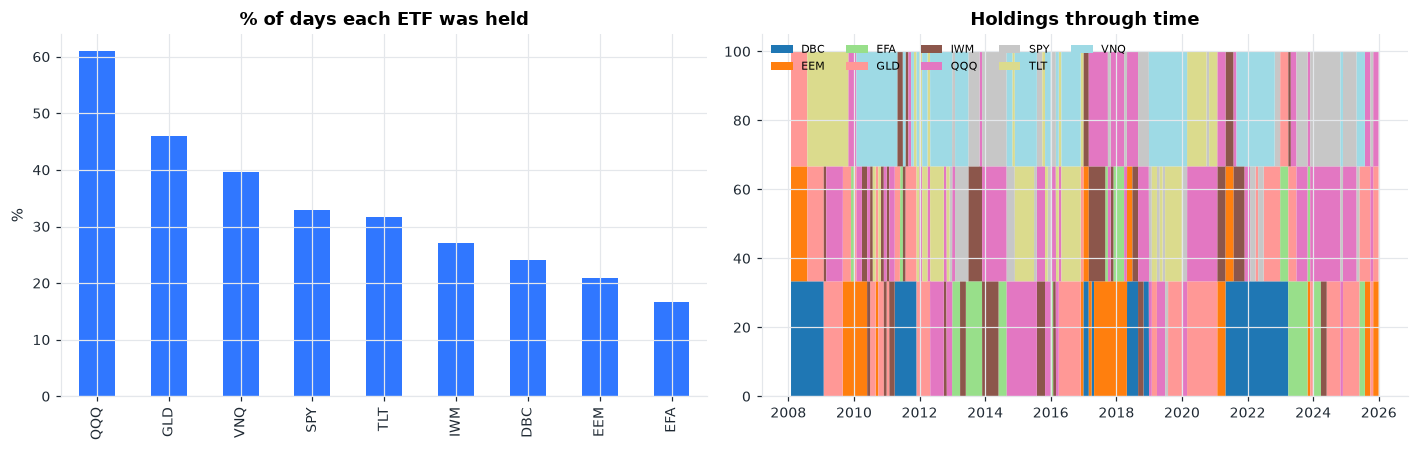

In [10]:
held = (weights > 0).loc[weights.sum(axis=1) > 0]
frequency = (held.sum() / len(held)).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
(frequency * 100).plot.bar(ax=axes[0], color="#0B5FFF", alpha=0.85)
axes[0].set_title("% of days each ETF was held")
axes[0].set_ylabel("%")

w = weights.loc[weights.sum(axis=1) > 0]
axes[1].stackplot(w.index, *[w[c].values * 100 for c in w.columns],
                  labels=list(w.columns), colors=plt.cm.tab20(np.linspace(0, 1, len(w.columns))))
axes[1].set_title("Holdings through time")
axes[1].legend(ncol=5, fontsize=7, loc="upper left")
plt.tight_layout()

frequency.round(3)

## Turnover

In [11]:
from quant_platform.costs import compute_turnover

executed = weights.shift(1).fillna(0.0)
turnover = compute_turnover(executed)

print(f"annual turnover (two-way): {metrics.annual_turnover(turnover):.2f}x")
print(f"one-way equivalent:        {metrics.annual_turnover(turnover) / 2:.2f}x")
print(f"rebalances with any trade: {(turnover > 1e-9).sum()} of {len(reb)}")
print(f"mean turnover when trading: {turnover[turnover > 1e-9].mean():.3f}")

annual turnover (two-way): 4.13x
one-way equivalent:        2.07x
rebalances with any trade: 107 of 228
mean turnover when trading: 0.732


## Takeaways

1. The score matches hand arithmetic at the individual-cell level.
2. The skip window verifiably excludes the most recent 21 prices.
3. Rebalance dates are real trading days — and roughly a third of calendar month-ends are not,
   which is exactly the trap the platform avoids.
4. Selections match a manual ranking at every date checked.
5. Weights are genuinely constant between rebalances.

Next: `03_results.ipynb`.